In [1]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
DEVICE = 0
SEED = 42
DECODER_TYPE  = 'nar-enc'

In [5]:
from torch.utils.data import DataLoader
from src.data import QuickDrawDataset

test_dataset = QuickDrawDataset("../data/quickdraw/", split='test')
test_loader = DataLoader(test_dataset, batch_size=512, collate_fn=QuickDrawDataset.collate_fn_padd, 
                                num_workers=8)

MAX_SKETCH_SIZE = 0
for data in test_dataset:
    MAX_SKETCH_SIZE = max(MAX_SKETCH_SIZE, data['pos_absolute'].shape[0])

In [ ]:
#FROM https://stackoverflow.com/questions/75545944/efficient-algorithm-for-online-variance-update-over-batched-data-color-channel
def combine_means(mu1, mu2, m, n):
    """
    Updates old mean mu1 from m samples with mean mu2 of n samples.
    Returns the mean of the m+n samples.
    """

    total = total.clamp(min=1)
    return (m/total)*mu1 + (n/total)*mu2

def combine_vars(v1, v2, mu1, mu2, m, n):
    """
    Updates old variance v1 from m samples with variance v2 of n samples.
    Returns the variance of the m+n samples.
    """

    total = (m+n).clamp(min=1)
    return (m/total)*v1 + (n/total)*v2 + m*n/(total**2) * (mu1 - mu2)**2

In [ ]:
import pickle as pkl
import torch
from src.lightning_models import LtSketchReconstruction
from src.models import Sketchformer, BlockConfig, PosEmbeddingConfig
from src.data import InputHandler, OutputHandler

cumulative_error_stats = {}

for coord_type in ['rel_rel', 'rel_abs', 'abs_rel', 'abs_abs']:
    with open(f"../sketch_representations/results/experiment2/{coord_type}_{DECODER_TYPE}_{SEED}.pkl", "rb") as file:
            results = pkl.load(file)

    checkpoint = torch.load(f"../sketch_representations/checkpoints/experiment2/{coord_type}_{DECODER_TYPE}_{SEED}/best.ckpt", map_location='cpu')

    sketchformer = Sketchformer(
        hidden_dim=results['args']['hidden_dim'],
        num_encoder_layers=results['args']['num_encoder_layers'],
        num_decoder_layers=results['args']['num_decoder_layers'],
        decoder_type=results['args']['decoder_type'],
        block_config=BlockConfig(
            dropout=results['args']['hidden_dropout']
        ),
        pos_embedding_config=PosEmbeddingConfig(
            pen_state=results['args']['pen_state'], 
            stroke_embedding=results['args']['stroke_embedding'], 
            sketch_pos=results['args']['sketch_pos'],
            stroke_pos=results['args']['stroke_pos']
        )
    )

    input_handler = InputHandler(input_relative_coords=results['args']['input_relative_coords'], output_relative_coords=results['args']['output_relative_coords'], autoencoder=True, autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"], mode='test')
    output_handler = OutputHandler(output_relative_coords=results['args']['output_relative_coords'], autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"], mode='test')
    model = LtSketchReconstruction(sketchformer, input_handler, output_handler, results['args']['lr'])
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    model = model.cuda(DEVICE)

    cumulative_error_stats[coord_type] = {}
    cumulative_error_stats[coord_type]['mean'] = torch.zeros(MAX_SKETCH_SIZE)
    cumulative_error_stats[coord_type]['var'] = torch.zeros(MAX_SKETCH_SIZE)
    cumulative_error_stats[coord_type]['total'] = torch.zeros(MAX_SKETCH_SIZE)

    for batch in test_loader:
        batch = {k: v.cuda(DEVICE) for k, v in batch.items()}
        with torch.no_grad():
            preds, targets, mask = model(batch)

        l2 = ((preds - targets)**2).sum(dim=-1)
        mask = mask.float()

        cumulative_error = l2 * mask

        valid_counts = mask.sum(dim=0)

        mu1 = cumulative_error_stats[coord_type]['mean']
        var1 = cumulative_error_stats[coord_type]['var']
        m = cumulative_error_stats[coord_type]['total']

        mu2 = cumulative_error.sum(dim=0) / valid_counts.clamp(min=1)
        var2 = (((cumulative_error - mu2) * mask) ** 2).sum(dim=0) / valid_counts.clamp(min=1)
        n = valid_counts

        mu2 = torch.nn.functional.pad(mu2, (0, mu1.shape[0] - mu2.shape[0])).cpu()
        var2 = torch.nn.functional.pad(var2, (0, var1.shape[0] - var2.shape[0])).cpu()
        n = torch.nn.functional.pad(n, (0, m.shape[0] - n.shape[0])).cpu()

        cumulative_error_stats[coord_type]['mean'] = combine_means(mu1, mu2, m, n)
        cumulative_error_stats[coord_type]['var'] = combine_vars(var1, var2, mu1, mu2, m, n)
        cumulative_error_stats[coord_type]['total'] += n


    cumulative_error_stats[coord_type]['std'] = cumulative_error_stats[coord_type]['var'].sqrt()

In [ ]:
torch.save(cumulative_error_stats, "../cumulative_error.pt")

In [3]:
import torch
cumulative_error_stats = torch.load("../cumulative_error.pt")

In [6]:
from torch.utils.data import DataLoader
from src.data import QuickDrawDataset

train_dataset = QuickDrawDataset("../data/quickdraw/", split='train')
test_dataset = QuickDrawDataset("../data/quickdraw/", split='test')

hists = (torch.zeros(len(train_dataset)), torch.zeros(len(test_dataset)))

for i, dataset in enumerate((train_dataset, test_dataset)):
    for j, data in enumerate(dataset):
        hists[i][j] = data['pos_absolute'].shape[0]

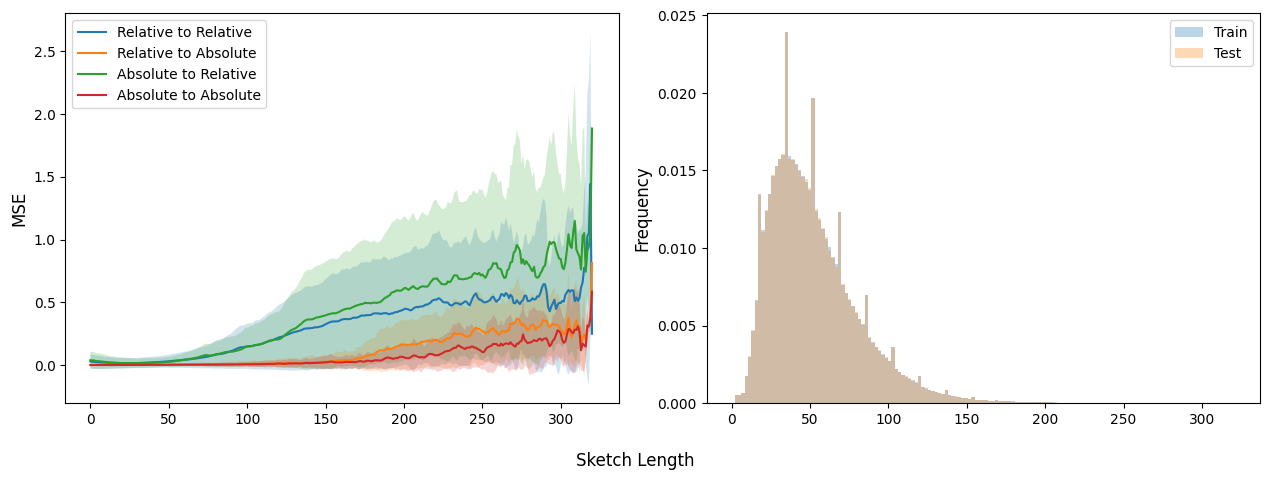

In [11]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1, 2, figsize=(6.4*2, 4.8),  sharex=True)

axis[0].plot(cumulative_error_stats['rel_rel']['mean'], label='Relative to Relative')
axis[0].fill_between(
        torch.arange(cumulative_error_stats['rel_rel']['mean'].shape[0]),
        cumulative_error_stats['rel_rel']['mean'] - cumulative_error_stats['rel_rel']['std'],
        cumulative_error_stats['rel_rel']['mean'] + cumulative_error_stats['rel_rel']['std'],
        alpha=0.2)

axis[0].plot(cumulative_error_stats['rel_abs']['mean'], label='Relative to Absolute')
axis[0].fill_between(
        torch.arange(cumulative_error_stats['rel_abs']['mean'].shape[0]),
        cumulative_error_stats['rel_abs']['mean'] - cumulative_error_stats['rel_abs']['std'],
        cumulative_error_stats['rel_abs']['mean'] + cumulative_error_stats['rel_abs']['std'],
        alpha=0.2)

axis[0].plot(cumulative_error_stats['abs_rel']['mean'], label='Absolute to Relative')
axis[0].fill_between(
        torch.arange(cumulative_error_stats['abs_rel']['mean'].shape[0]),
        cumulative_error_stats['abs_rel']['mean'] - cumulative_error_stats['abs_rel']['std'],
        cumulative_error_stats['abs_rel']['mean'] + cumulative_error_stats['abs_rel']['std'],
        alpha=0.2)

axis[0].plot(cumulative_error_stats['abs_abs']['mean'], label='Absolute to Absolute')
axis[0].fill_between(
        torch.arange(cumulative_error_stats['abs_abs']['mean'].shape[0]),
        cumulative_error_stats['abs_abs']['mean'] - cumulative_error_stats['abs_abs']['std'],
        cumulative_error_stats['abs_abs']['mean'] + cumulative_error_stats['abs_abs']['std'],
        alpha=0.2)

#axis[0].set_xlabel("Sketch Length")
axis[0].set_ylabel("MSE", size="12")
axis[0].legend()

# axis[1].plot(cumulative_error_stats['abs_abs']['total'] / cumulative_error_stats['abs_abs']['total'].sum())
# axis[1].set_ylabel("Frequency")
# axis[1].set_xlabel("Sketch Length")

# hist = torch.cat((cumulative_error_stats['abs_abs']['total'].flip(dims=(0,)).diff().flip(dims=(0,)), cumulative_error_stats['abs_abs']['total'][[-1]])).to(torch.int)
# values = torch.arange(len(hist)) 
# raw_data = torch.repeat_interleave(values+1, hist)
axis[1].hist(hists[0], bins=150, alpha=0.3, density=True, label='Train')
axis[1].hist(hists[1], bins=150, alpha=0.3, density=True, label='Test')
axis[1].set_ylabel("Frequency", size="12")
axis[1].legend()
#axis[1].set_xlabel("Sketch Length")

fig.supxlabel("Sketch Length")
fig.tight_layout()
fig.savefig("../error_length.svg")